# House Prices — Advanced Regression Techniques

Predicting residential sale prices for Ames, Iowa (79 features, 1,460 training rows).
Scored on RMSE between the **log** of predicted and actual `SalePrice`.

**Result:** 326th / ~3,200 (top ~10%), 5-fold CV RMSE ≈ 0.110.

Approach in brief: domain-aware cleaning -> ordinal + one-hot encoding -> a few
engineered features -> skew correction -> a blend of Lasso, Ridge and gradient boosting.

In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/datasets/mylesfairburn/housingdata/sample_submission.csv
/kaggle/input/datasets/mylesfairburn/housingdata/data_description.txt
/kaggle/input/datasets/mylesfairburn/housingdata/train.csv
/kaggle/input/datasets/mylesfairburn/housingdata/test.csv


### CSVs Loaded 
Column names displayed

In [75]:
train = pd.read_csv('../input/datasets/mylesfairburn/housingdata/train.csv')
test = pd.read_csv('../input/datasets/mylesfairburn/housingdata/test.csv')

train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Save training SalePrice
Combine dataframes to complete data engineering, store training length to split back

In [76]:
ntrain = len(train)
y = train['SalePrice']
train = train.drop(columns=['SalePrice'])

combined = pd.concat([train, test], axis=0).reset_index(drop=True)

### Target: `SalePrice`

`SalePrice` is right-skewed and the metric is RMSE on its log, so every model is trained on `log1p(SalePrice)`. Predictions are inverted with `expm1`, this aligns training with how submissions are scored.

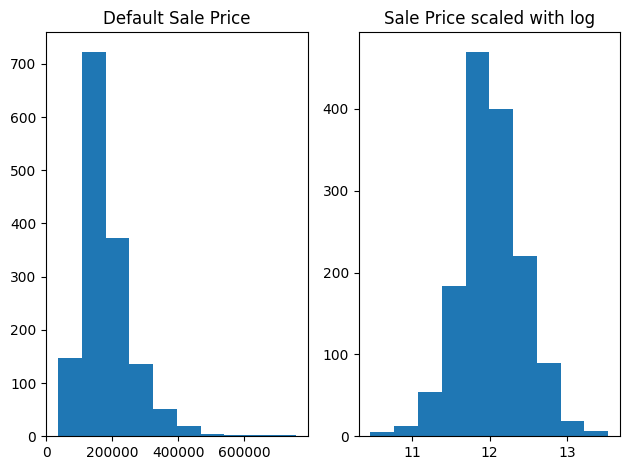

In [77]:
import matplotlib.pyplot as plt

salePrice = y

plt.subplot(1, 2, 1)
plt.hist(salePrice)
plt.title('Default Sale Price')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(salePrice))
plt.title('Sale Price scaled with log')

plt.tight_layout()

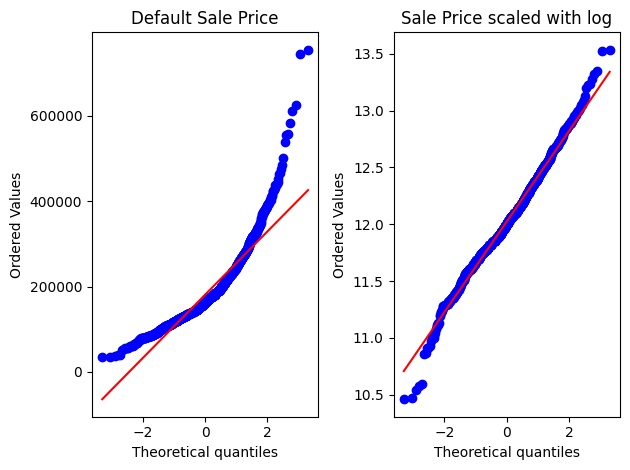

In [78]:
import scipy
from scipy import stats

plt.subplot(1, 2, 1)
stats.probplot(salePrice, plot=plt)
plt.title('Default Sale Price')

plt.subplot(1, 2, 2)
stats.probplot(np.log1p(salePrice), plot=plt)
plt.title('Sale Price scaled with log')

plt.tight_layout()
plt.show()

### Categorise and correct columns

In [79]:
combined['MSSubClass'] = combined['MSSubClass'].astype(str)
combined['MoSold'] = combined['MoSold'].astype(str)

### Handling missing values

Most "missing" values aren't truly missing, outlined in the data_description. `NA` means the feature is absent (no pool, no basement), so those become `"None"` or `0`. Genuinely missing categoricals take the column mode, and `LotFrontage` uses the median for its neighbourhood rather than a global median.

In [80]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'BsmtQual', 'BsmtCond',
             'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'Fence', 'MasVnrType']
for col in none_cols:
    combined[col] = combined[col].fillna("None")

zero_cols = ['MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF',
             'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF', 'GarageArea', 'GarageCars']
for col in zero_cols:
    combined[col] = combined[col].fillna(0)

In [81]:
combined = combined.drop(columns=['GarageYrBlt'])

In [82]:
for col in ['MSZoning','Electrical','KitchenQual','Exterior1st','Exterior2nd','SaleType']:
    combined[col] = combined[col].fillna(combined[col].mode()[0])
combined['Functional'] = combined['Functional'].fillna('Typ')

In [83]:
combined['LotFrontage'] = combined.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [84]:
combined.isna().sum()
na_counts = combined.isna().sum()
na_counts[na_counts > 0].sort_values(ascending=False)

Utilities    2
dtype: int64

### Encoding

Quality fields are ordinal, `Po < Fa < TA < Gd < Ex`. So they're mapped to integers to preserve that ordering, which one-hot encoding would discard. Purely nominal fields (neighbourhood, roof style ect..) are one-hot encoded instead.

In [85]:
# numeric
numeric = ['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
    'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea',
    'BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr',
    'KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars','GarageArea',
    'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch',
    'PoolArea','MiscVal','YearBuilt','YearRemodAdd','YrSold',
    'OverallQual','OverallCond']

# nominal
nominal = ['MSSubClass','MSZoning','Street','Alley','LandContour','Utilities',
    'LotConfig','Neighborhood','Condition1','Condition2','BldgType','HouseStyle',
    'RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation',
    'Heating','Electrical','GarageType','Fence','MiscFeature','SaleType',
    'SaleCondition','MoSold']

In [86]:
qual_map = {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}
for col in ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
            'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']:
    combined[col] = combined[col].map(qual_map)

combined['BsmtExposure'] = combined['BsmtExposure'].map({'None':0,'No':1,'Mn':2,'Av':3,'Gd':4})
fin_map = {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6}
combined['BsmtFinType1'] = combined['BsmtFinType1'].map(fin_map)
combined['BsmtFinType2'] = combined['BsmtFinType2'].map(fin_map)
combined['GarageFinish'] = combined['GarageFinish'].map({'None':0,'Unf':1,'RFn':2,'Fin':3})
combined['Functional']   = combined['Functional'].map(
    {'Sal':0,'Sev':1,'Maj2':2,'Maj1':3,'Mod':4,'Min2':5,'Min1':6,'Typ':7})
combined['LotShape']  = combined['LotShape'].map({'IR3':0,'IR2':1,'IR1':2,'Reg':3})
combined['LandSlope'] = combined['LandSlope'].map({'Sev':0,'Mod':1,'Gtl':2})
combined['PavedDrive']= combined['PavedDrive'].map({'N':0,'P':1,'Y':2})
combined['CentralAir']= combined['CentralAir'].map({'N':0,'Y':1})

### Feature engineering

A few features that capture what buyers actually value: total living area across floors and basement (`TotalSF`), total bathrooms, house/remodel age and binary flags for a pool, garage, fireplace, second floor.

In [87]:
combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']
combined['TotalBath'] = (combined['FullBath'] + 0.5*combined['HalfBath']
                         + combined['BsmtFullBath'] + 0.5*combined['BsmtHalfBath'])
combined['TotalPorchSF'] = (combined['OpenPorchSF'] + combined['EnclosedPorch']
                            + combined['3SsnPorch'] + combined['ScreenPorch']
                            + combined['WoodDeckSF'])
combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']
combined['RemodAge'] = combined['YrSold'] - combined['YearRemodAdd']

combined['HasPool']      = (combined['PoolArea'] > 0).astype(int)
combined['HasGarage']    = (combined['GarageArea'] > 0).astype(int)
combined['HasFireplace'] = (combined['Fireplaces'] > 0).astype(int)
combined['Has2ndFloor']  = (combined['2ndFlrSF'] > 0).astype(int)

### One-hot encoding

In [88]:
combined = pd.get_dummies(combined, columns=nominal, drop_first=False)

print("Object cols left:", list(combined.select_dtypes('object').columns)) 
print("NAs left:", combined.isna().sum().sum())

Object cols left: []
NAs left: 0


### Separate datasets

In [89]:
X_train = combined.iloc[:ntrain].copy()
X_test  = combined.iloc[ntrain:].copy()

X_train['SalePrice'] = y.values

### Removing outliers

A few of the dataset's author flags are oversized, underpriced homes (partial sales) as distortions. Dropping the homes with `GrLivArea > 4000` and a low price removes them without disturbing the rest.

In [90]:
X_train = X_train[~((X_train['GrLivArea'] > 4000) & (X_train['SalePrice'] < 300000))]

y_train = np.log1p(X_train['SalePrice'])
X_train = X_train.drop(columns=['SalePrice'])

### Save ID for submission

In [91]:
test_id = X_test['Id']
X_train = X_train.drop(columns=['Id'])
X_test  = X_test.drop(columns=['Id'])

### Import Libraries

In [92]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict,cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV, LassoCV


### Modelling

Two complementary approaches: regularised linear models (Ridge, Lasso) that cope well with the many one-hot columns and gradient boosting (`HistGradientBoostingRegressor`) for non-linear interactions. Final blend weights are chosen on **out-of-fold** predictions, so they aren't tuned on data the models already saw.

In [93]:
model = HistGradientBoostingRegressor(random_state=42, max_iter=500, learning_rate=0.05)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train,scoring='neg_mean_squared_error', cv=kf)
rmse = np.sqrt(-scores)
print(f"CV RMSE (log scale): {rmse.mean():.5f} +/- {rmse.std():.5f}")

CV RMSE (log scale): 0.12677 +/- 0.00581


In [94]:
model.fit(X_train, y_train)
result = permutation_importance(model, X_train, y_train, n_repeats=5, random_state=42, n_jobs=-1)
importances = pd.Series(result.importances_mean, index=X_train.columns)
print(importances.sort_values(ascending=False).head(20))

TotalSF         0.270750
OverallQual     0.164233
OverallCond     0.018444
GrLivArea       0.015631
LotArea         0.010951
TotalBath       0.009239
HouseAge        0.006932
KitchenQual     0.006216
GarageArea      0.006081
RemodAge        0.005525
TotalPorchSF    0.005422
BsmtFinSF1      0.005069
CentralAir      0.004608
GarageCars      0.004559
1stFlrSF        0.004550
BsmtUnfSF       0.003692
YearBuilt       0.003040
FireplaceQu     0.002840
YearRemodAdd    0.002701
LotFrontage     0.002569
dtype: float64


In [95]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = make_pipeline(RobustScaler(), Ridge(alpha=10))
gbr   = HistGradientBoostingRegressor(random_state=42, max_iter=500, learning_rate=0.05)

oof_ridge = cross_val_predict(ridge, X_train, y_train, cv=kf, n_jobs=-1)
oof_gbr   = cross_val_predict(gbr,   X_train, y_train, cv=kf, n_jobs=-1)

def rmse(y, p): return np.sqrt(mean_squared_error(y, p))
print(f"Ridge alone: {rmse(y_train, oof_ridge):.5f}")
print(f"GBR alone:   {rmse(y_train, oof_gbr):.5f}")

for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    blend = w*oof_gbr + (1-w)*oof_ridge
    print(f"w_gbr={w:.1f}: {rmse(y_train, blend):.5f}")

Ridge alone: 0.11456
GBR alone:   0.12691
w_gbr=0.3: 0.11217
w_gbr=0.4: 0.11259
w_gbr=0.5: 0.11360
w_gbr=0.6: 0.11521
w_gbr=0.7: 0.11737


### Correcting skew

Several area features are heavily right-skewed; `log1p` brings them closer to normal which the linear models in particular benefit from.

In [96]:
from scipy.stats import skew

skew_candidates = ['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
    'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea',
    'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch',
    'PoolArea','MiscVal','TotalSF','TotalPorchSF']

skews = X_train[skew_candidates].apply(skew).sort_values(ascending=False)
skewed = skews[abs(skews) > 0.5].index
print(skews.round(2))

for col in skewed:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

MiscVal          24.43
PoolArea         15.93
LotArea          12.56
3SsnPorch        10.29
LowQualFinSF      9.00
BsmtFinSF2        4.25
ScreenPorch       4.11
EnclosedPorch     3.08
MasVnrArea        2.69
OpenPorchSF       2.34
LotFrontage       1.55
WoodDeckSF        1.54
TotalPorchSF      1.10
GrLivArea         1.01
BsmtUnfSF         0.92
1stFlrSF          0.89
2ndFlrSF          0.81
TotalSF           0.80
BsmtFinSF1        0.76
TotalBsmtSF       0.51
dtype: float64


In [97]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse(y, p): return np.sqrt(mean_squared_error(y, p))

ridge = make_pipeline(RobustScaler(), RidgeCV(alphas=np.logspace(-1, 2, 30)))
lasso = make_pipeline(RobustScaler(), LassoCV(alphas=np.logspace(-4, -1, 30), max_iter=10000, random_state=42))

oof_ridge = cross_val_predict(ridge, X_train, y_train, cv=kf, n_jobs=-1)
oof_lasso = cross_val_predict(lasso, X_train, y_train, cv=kf, n_jobs=-1)

print(f"RidgeCV: {rmse(y_train, oof_ridge):.5f}")
print(f"LassoCV: {rmse(y_train, oof_lasso):.5f}")
print(f"GBR:     {rmse(y_train, oof_gbr):.5f}")

for wl in [0.3, 0.4, 0.5]:
    for wg in [0.2, 0.3]:
        blend = wl*oof_lasso + wg*oof_gbr + (1-wl-wg)*oof_ridge
        print(f"lasso={wl} gbr={wg} ridge={1-wl-wg:.1f}: {rmse(y_train, blend):.5f}")

RidgeCV: 0.11403
LassoCV: 0.11142
GBR:     0.12691
lasso=0.3 gbr=0.2 ridge=0.5: 0.11076
lasso=0.3 gbr=0.3 ridge=0.4: 0.11067
lasso=0.4 gbr=0.2 ridge=0.4: 0.11045
lasso=0.4 gbr=0.3 ridge=0.3: 0.11037
lasso=0.5 gbr=0.2 ridge=0.3: 0.11019
lasso=0.5 gbr=0.3 ridge=0.2: 0.11013


### Submission Data

In [98]:
w_lasso, w_gbr, w_ridge = 0.45, 0.3, 0.25

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
gbr.fit(X_train, y_train)

pred_log = (w_lasso*lasso.predict(X_test) + w_gbr*gbr.predict(X_test) + w_ridge*ridge.predict(X_test))
preds = np.expm1(pred_log)

submission = pd.DataFrame({'Id': test_id, 'SalePrice': preds})
submission.to_csv('submission.csv', index=False)

## Progression through model tuning

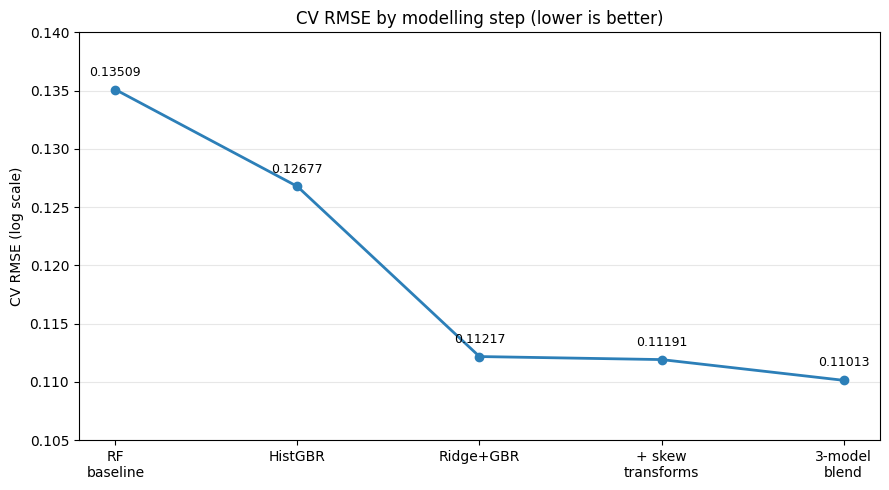

In [99]:
os.makedirs('assets', exist_ok=True)

steps = ['RF\nbaseline', 'HistGBR', 'Ridge+GBR', '+ skew\ntransforms', '3-model\nblend']
rmse  = [0.13509, 0.12677, 0.11217, 0.11191, 0.11013]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, rmse, marker='o', linewidth=2, color='#2c7fb8')
for x, y in zip(steps, rmse):
    ax.annotate(f'{y:.5f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_ylabel('CV RMSE (log scale)')
ax.set_title('CV RMSE by modelling step (lower is better)')
ax.set_ylim(0.105, 0.14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('assets/progression.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

A RandomForest baseline set the starting point at ~0.135 CV RMSE. Iterating from there, I switched to gradient boosting, then to regularised linear models, and correcting skew which brought the final blend to ~0.110 CV RMSE and 326th / ~3,200 on the leaderboard (top ~10%). The largest gains came from the linear models and skew correction, not from the tree model alone.

**Caveat / next steps:** preprocessing is fit on train and test combined, which leaks test statistics. That's tolerated in a getting-started competition, but in production I'd fit every transform on train only inside an sklearn `Pipeline`. Further gains would likely come from target encoding for high-cardinality categoricals and from stacking rather than a fixed-weight blend.